# Apartment Rent Prediction (CRISP-DM)

**BMDS2003 Data Science Project — Group 4**

Regression: predict monthly apartment rent (USD). <br>Dataset: UCI Apartment for Rent Classified (100K). <br>Models: Linear Regression (baseline), Decision Tree, Random Forest, Hist Gradient Boosting. Each model section includes three diagnostic graphs. Metrics: MAE, RMSE, R2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import seaborn as sns


# Step 1: Data Understanding

In [2]:
df = pd.read_csv('apartments_for_rent_classified_100K.csv', sep=';', encoding='cp1252', low_memory=False)
df.shape

(99492, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

In [4]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [5]:
df.tail()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
99487,5121219946,housing/rent/apartment,Houston - superb Apartment nearby fine dining,"Redefining urban living, in southeast Houston,...","Gym,Parking,Patio/Deck,Playground,Storage,Wood...",1.0,1.0,USD,No,Yes,...,$780,Monthly,605,NaN,Houston,TX,29.6151,-95.1998,RentDigs.com,1544185770
99488,5121219696,housing/rent/apartment,The Best of the Best in the City of Jacksonvil...,Courtney Manor Apartments offer the best of ev...,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gym...",2.0,2.0,USD,No,Yes,...,$813,Monthly,921,NaN,Jacksonville,FL,30.2254,-81.7579,RentDigs.com,1544185750
99489,5121219420,housing/rent/apartment,A great & large One BR apartment. Pet OK!,"Fully remodeled, new floor, kitchen cabinet, s...","Garbage Disposal,Refrigerator",1.0,1.0,USD,No,Yes,...,"$1,325",Monthly,650,NaN,San Diego,CA,32.7379,-117.0914,RentDigs.com,1544185729
99490,5121218935,housing/rent/apartment,"The Crest offers studio, 1, 2 & Three BR homes...","Amenities include a fitness facilities, swimmi...","Gym,Pool",1.0,1.0,USD,No,Yes,...,$931,Monthly,701,NaN,Huntersville,NC,35.4158,-80.8451,RentDigs.com,1544185670
99491,5121218844,housing/rent/apartment,Large Remodeled Two BR 1. Five BA Apartment Home,This is a brand new 2 Beds 1. five Bathrooms A...,"Gated,Parking,Wood Floors",1.5,2.0,USD,No,Yes,...,"$1,595",Monthly,900,NaN,San Diego,CA,32.7379,-117.0914,RentDigs.com,1544185659


In [6]:
df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9.949200e+04,99429.000000,99368.000000,99491.000000,99492.000000,99467.000000,99467.000000,9.949200e+04
mean,5.358321e+09,1.445323,1.728212,1527.057281,956.430688,36.947988,-91.568656,1.559665e+09
std,1.847404e+08,0.547021,0.749200,904.245882,417.571522,4.599461,15.817168,1.105077e+07
min,5.121046e+09,1.000000,0.000000,100.000000,101.000000,19.573800,-159.369800,1.544174e+09
25%,5.197950e+09,1.000000,1.000000,1013.000000,729.000000,33.746500,-104.791900,1.550832e+09
50%,5.508673e+09,1.000000,2.000000,1350.000000,900.000000,37.228200,-84.562300,1.568745e+09
75%,5.509007e+09,2.000000,2.000000,1795.000000,1115.000000,39.953000,-77.608200,1.568767e+09
max,5.669439e+09,9.000000,9.000000,52500.000000,50000.000000,64.833200,-68.778800,1.577391e+09


In [7]:
# Null value detection
print(df.isnull().sum())

id                   0
category             0
title                0
body                 0
amenities        16044
bathrooms           63
bedrooms           124
currency             0
fee                  0
has_photo            0
pets_allowed     60424
price                1
price_display        1
price_type           0
square_feet          0
address          91549
cityname           302
state              302
latitude            25
longitude           25
source               0
time                 0
dtype: int64


In [8]:
print(df.duplicated().sum())

84


In [9]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
79465,5195387513,housing/rent/apartment,Townhome like Duplex,Lemon Grove two Level Upgraded 2 Beds attached...,"Dishwasher,Washer Dryer",1.5,2.0,USD,No,Thumbnail,...,"$2,450",Monthly,820,7241 Balkis,Lemon Grove,CA,32.7331,-117.0332,RentDigs.com,1550653888
83210,5195387513,housing/rent/apartment,Townhome like Duplex,Lemon Grove two Level Upgraded 2 Beds attached...,"Dishwasher,Washer Dryer",1.5,2.0,USD,No,Thumbnail,...,"$2,450",Monthly,820,7241 Balkis,Lemon Grove,CA,32.7331,-117.0332,RentDigs.com,1550653888
79464,5197678700,housing/rent/apartment,This Apartment is a must see!,"Square footage: 983 square ft, unit number: 07...",NaN,1.0,3.0,USD,No,Yes,...,"$1,489",Monthly,983,NaN,Memphis,TN,35.1478,-90.0521,RentDigs.com,1550812916
83209,5197678700,housing/rent/apartment,This Apartment is a must see!,"Square footage: 983 square ft, unit number: 07...",NaN,1.0,3.0,USD,No,Yes,...,"$1,489",Monthly,983,NaN,Memphis,TN,35.1478,-90.0521,RentDigs.com,1550812916
79463,5197682059,housing/rent/apartment,"Spacious One BR, One BA","The of Olathe, a great you canhome where we ta...","Gym,Playground,Pool",1.0,1.0,USD,No,Yes,...,$832,Monthly,660,NaN,Olathe,KS,38.8843,-94.8710,RentDigs.com,1550813171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41960,5508806391,housing/rent/apartment,Apartment in move in condition in District Hei...,Capital Courts has something for everyone. Loc...,"AC,Parking,Playground,Pool",1.5,3.0,USD,No,Yes,...,"$1,320",Monthly,943,NaN,District Heights,MD,38.8516,-76.8871,RentDigs.com,1568754069
41915,5508806428,housing/rent/apartment,Northglenn Value. Pet OK!,"Square footage: 738 square ft, unit number: 06...","Gym,Parking,Pool,Storage",1.0,1.0,USD,No,Yes,...,"$1,331",Monthly,738,NaN,Northglenn,CO,39.8999,-104.9442,RentDigs.com,1568754072
41959,5508806428,housing/rent/apartment,Northglenn Value. Pet OK!,"Square footage: 738 square ft, unit number: 06...","Gym,Parking,Pool,Storage",1.0,1.0,USD,No,Yes,...,"$1,331",Monthly,738,NaN,Northglenn,CO,39.8999,-104.9442,RentDigs.com,1568754072
41914,5508806580,housing/rent/apartment,"Las Vegas, prime location Two BR, Apartment. P...",Live in the middle of it all! South is a pet f...,"Gym,Parking,Pool",2.0,2.0,USD,No,Yes,...,"$1,335",Monthly,1084,NaN,Las Vegas,NV,36.1536,-115.1965,RentDigs.com,1568754086


# Step 2: Exploratory Data Analysis (EDA)

## 1. Univariate Analysis


#### Graph 1 (Univariate): Log-Transformed Monthly Rent Distribution


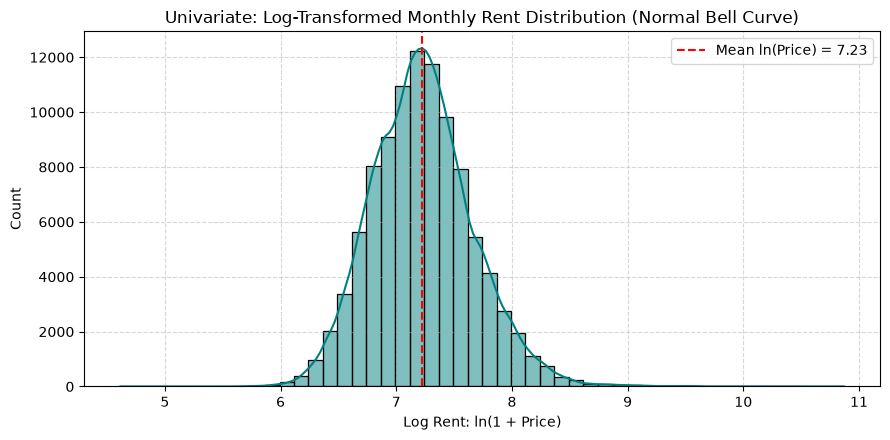

In [10]:
eda_df = df[df['price_type'] == 'Monthly'].copy()
for c in ['price', 'square_feet', 'bathrooms', 'bedrooms', 'latitude', 'longitude']:
    eda_df[c] = pd.to_numeric(eda_df[c], errors='coerce')

plt.figure(figsize=(9, 4.5))
log_prices = np.log1p(eda_df['price'].dropna())
sns.histplot(log_prices, bins=50, kde=True, color='teal')
plt.axvline(log_prices.mean(), color='red', linestyle='--', label=f'Mean ln(Price) = {log_prices.mean():.2f}')
plt.title('Univariate: Log-Transformed Monthly Rent Distribution (Normal Bell Curve)')
plt.xlabel('Log Rent: ln(1 + Price)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph1_log_price_distribution.png', dpi=140); plt.show()


#### Graph 2 (Univariate): Monthly Rent Histogram with KDE (Below 95th Percentile)


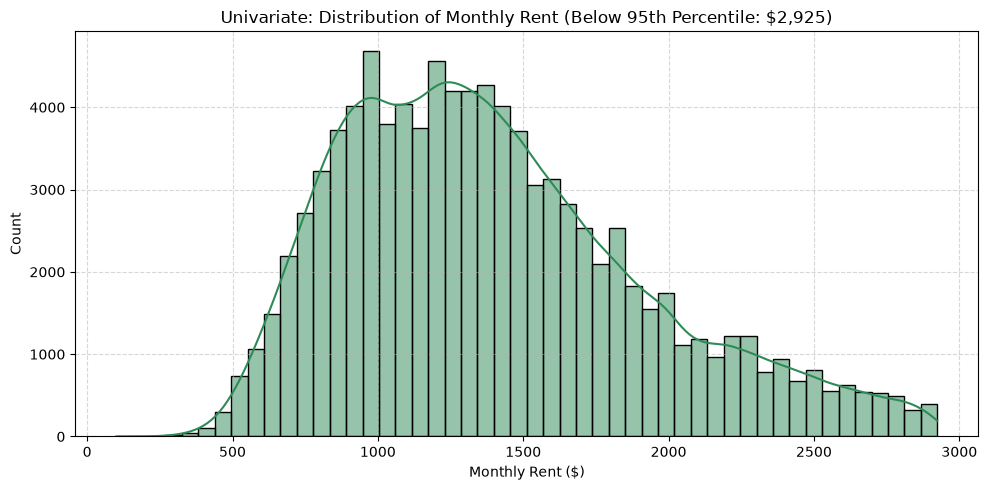

In [11]:
price_upper_bound = eda_df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.histplot(eda_df[eda_df['price'] < price_upper_bound]['price'], bins=50, kde=True, color='seagreen')
plt.title(f'Univariate: Distribution of Monthly Rent (Below 95th Percentile: ${price_upper_bound:,.0f})')
plt.xlabel('Monthly Rent ($)'); plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph2_price_hist_kde.png', dpi=140); plt.show()


#### Graph 3 (Univariate): Price and Square Feet Boxplots Before Outlier Removal


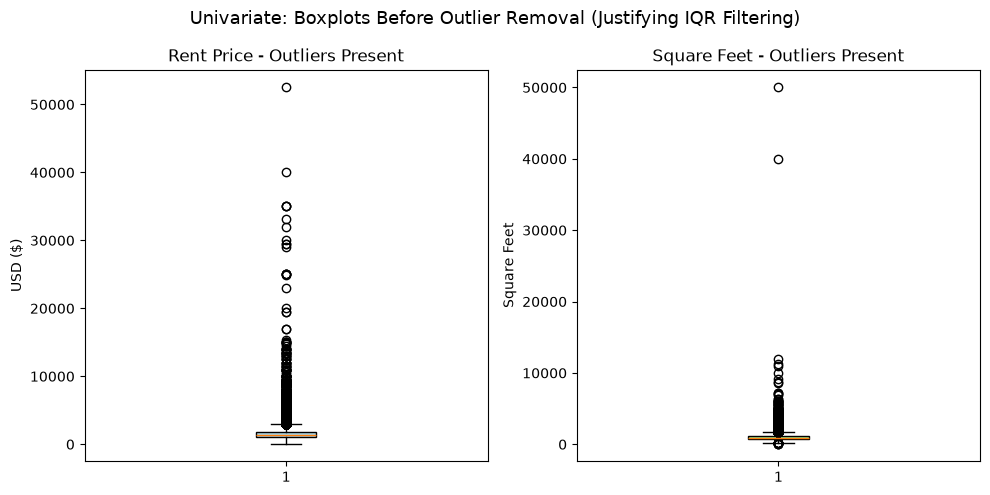

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(eda_df['price'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax[0].set_title('Rent Price - Outliers Present'); ax[0].set_ylabel('USD ($)')
ax[1].boxplot(eda_df['square_feet'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgreen'))
ax[1].set_title('Square Feet - Outliers Present'); ax[1].set_ylabel('Square Feet')
plt.suptitle('Univariate: Boxplots Before Outlier Removal (Justifying IQR Filtering)', fontsize=13)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph3_boxplots_before_iqr.png', dpi=140); plt.show()


#### Graph 4 (Univariate): Categorical Bar Charts (Fee and Photo Availability)


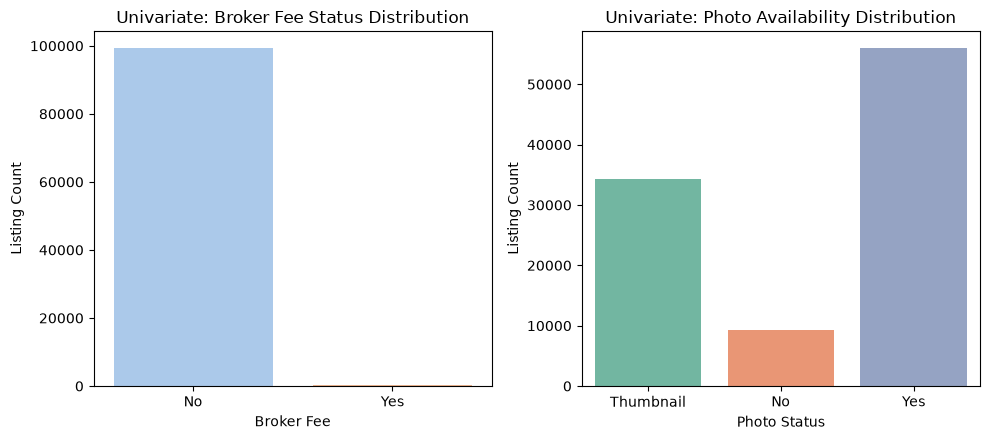

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
sns.countplot(data=eda_df, x='fee', palette='pastel', ax=ax[0], hue='fee', legend=False)
ax[0].set_title('Univariate: Broker Fee Status Distribution')
ax[0].set_xlabel('Broker Fee'); ax[0].set_ylabel('Listing Count')

sns.countplot(data=eda_df, x='has_photo', palette='Set2', ax=ax[1], hue='has_photo', legend=False)
ax[1].set_title('Univariate: Photo Availability Distribution')
ax[1].set_xlabel('Photo Status'); ax[1].set_ylabel('Listing Count')
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph4_categorical_bars.png', dpi=140); plt.show()


#### Graph 5 (Univariate): Distribution of Apartment Sizes (Square Feet)


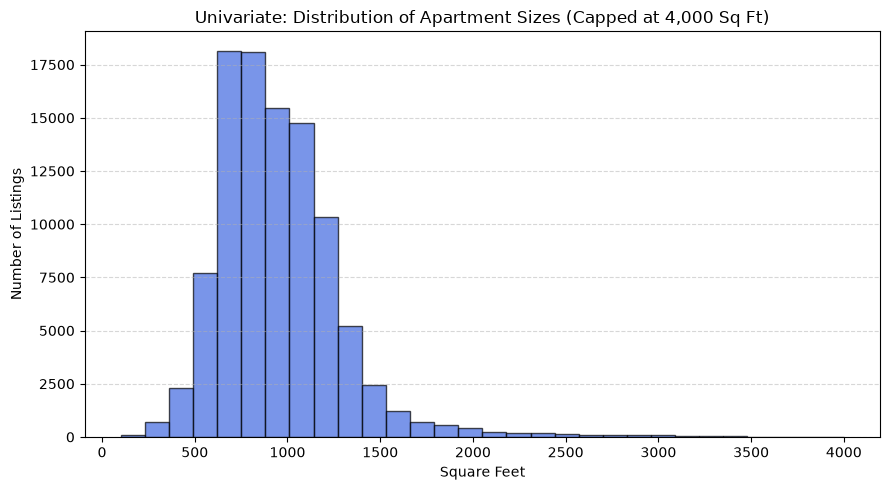

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(eda_df[eda_df['square_feet'] <= 4000]['square_feet'], bins=30, color='royalblue', edgecolor='black', alpha=0.7)
plt.title('Univariate: Distribution of Apartment Sizes (Capped at 4,000 Sq Ft)')
plt.xlabel('Square Feet'); plt.ylabel('Number of Listings')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph5_sqft_hist.png', dpi=140); plt.show()


## 2. Bivariate Analysis

#### Graph 6 (Bivariate): Correlation Heatmap of Numerical Features


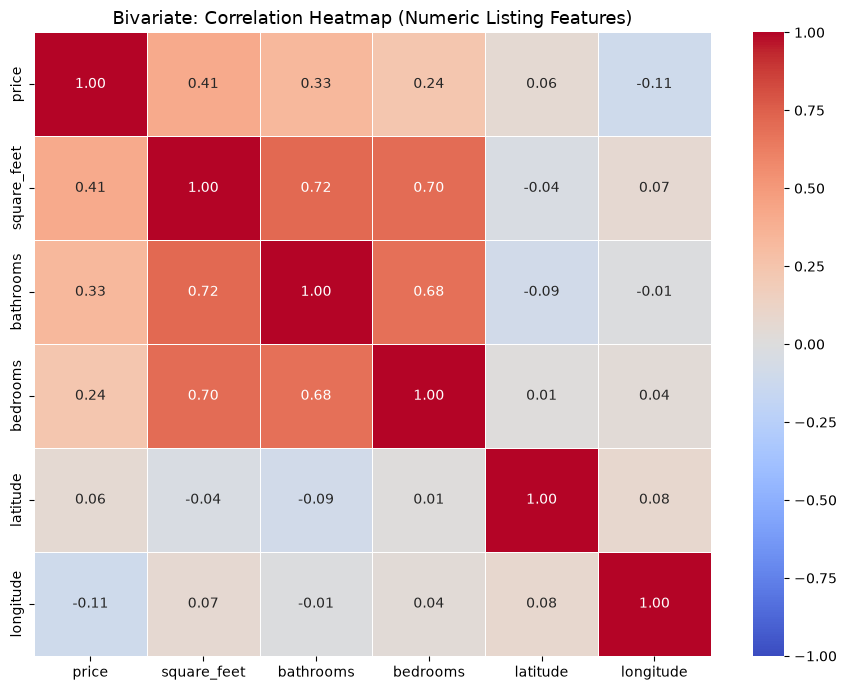

In [15]:
plt.figure(figsize=(9, 7))
numeric_cols = eda_df[['price', 'square_feet', 'bathrooms', 'bedrooms', 'latitude', 'longitude']].dropna()
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Bivariate: Correlation Heatmap (Numeric Listing Features)', fontsize=13)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph6_correlation_heatmap.png', dpi=140); plt.show()


#### Graph 7 (Bivariate): Rent Price vs Square Feet Scatter Plot by Bedrooms


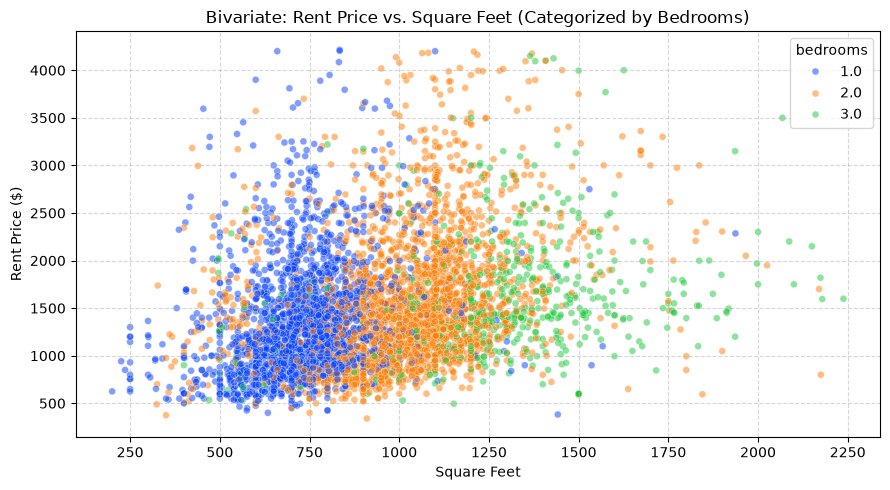

In [16]:
p99 = eda_df['price'].quantile(0.99)
sq99 = eda_df['square_feet'].quantile(0.99)
sample_bivariate = eda_df[(eda_df['price'] < p99) & (eda_df['square_feet'] < sq99) & (eda_df['bedrooms'].isin([1, 2, 3]))].sample(5000, random_state=42)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=sample_bivariate, x='square_feet', y='price', hue='bedrooms', palette='bright', alpha=0.5, s=25)
plt.title('Bivariate: Rent Price vs. Square Feet (Categorized by Bedrooms)')
plt.xlabel('Square Feet'); plt.ylabel('Rent Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph7_price_vs_sqft_scatter.png', dpi=140); plt.show()


#### Graph 8 (Bivariate): Average Rent Heatmap by Bedroom & Bathroom Configurations


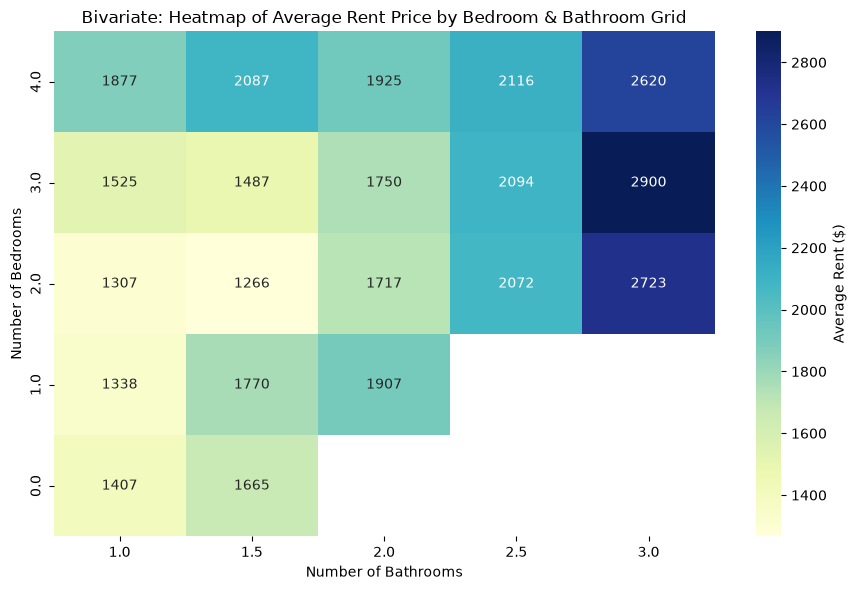

In [17]:
df_filtered_layout = eda_df[
    (eda_df['bedrooms'].isin([0, 1, 2, 3, 4])) & 
    (eda_df['bathrooms'].isin([1, 1.5, 2, 2.5, 3]))
]
price_matrix = df_filtered_layout.pivot_table(values='price', index='bedrooms', columns='bathrooms', aggfunc='mean')
plt.figure(figsize=(9, 6))
sns.heatmap(price_matrix, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Average Rent ($)'})
plt.title('Bivariate: Heatmap of Average Rent Price by Bedroom & Bathroom Grid')
plt.xlabel('Number of Bathrooms'); plt.ylabel('Number of Bedrooms')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph8_layout_matrix_heatmap.png', dpi=140); plt.show()


#### Graph 9 (Bivariate): Top 10 Most Common Apartment Layouts


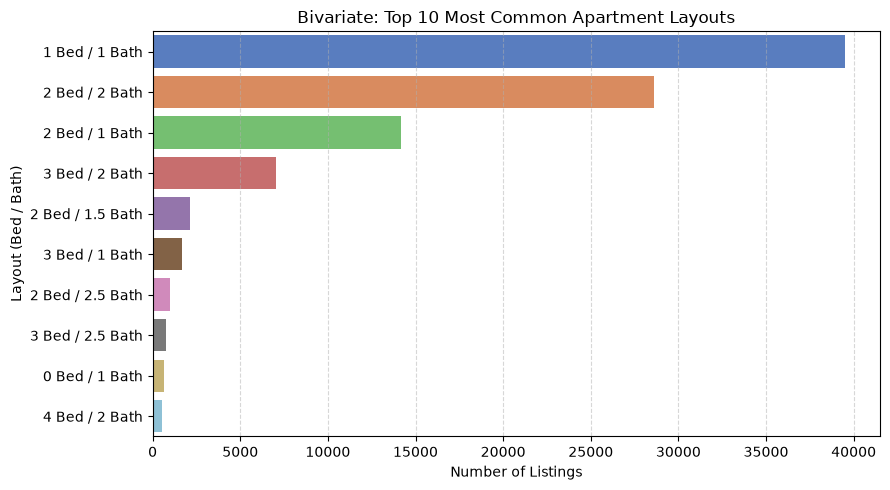

In [18]:
eda_df['beds_str'] = eda_df['bedrooms'].dropna().astype(str).str.split('.').str[0]
eda_df['baths_str'] = eda_df['bathrooms'].dropna().astype(str).str.replace(r'\.0$', '', regex=True)
eda_df['layout'] = eda_df['beds_str'] + ' Bed / ' + eda_df['baths_str'] + ' Bath'
top_layouts = eda_df['layout'].value_counts().nlargest(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_layouts.values, y=top_layouts.index, palette='muted', hue=top_layouts.index, legend=False)
plt.title('Bivariate: Top 10 Most Common Apartment Layouts')
plt.xlabel('Number of Listings'); plt.ylabel('Layout (Bed / Bath)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph9_top_layouts.png', dpi=140); plt.show()


#### Graph 10 (Bivariate): Rent Price Distribution by Number of Bedrooms


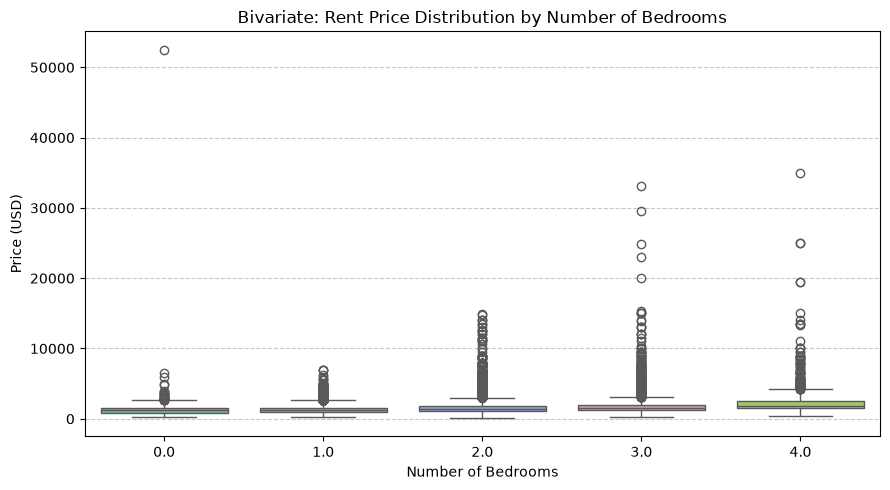

In [19]:
df_beds = eda_df[eda_df['bedrooms'].isin([0, 1, 2, 3, 4])]
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_beds, x='bedrooms', y='price', hue='bedrooms', palette='Set2', legend=False)
plt.title('Bivariate: Rent Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms'); plt.ylabel('Price (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph10_price_by_bedrooms.png', dpi=140); plt.show()


#### Graph 11 (Bivariate): Cross-Tabulation Heatmap (Photo Availability vs Broker Fee)


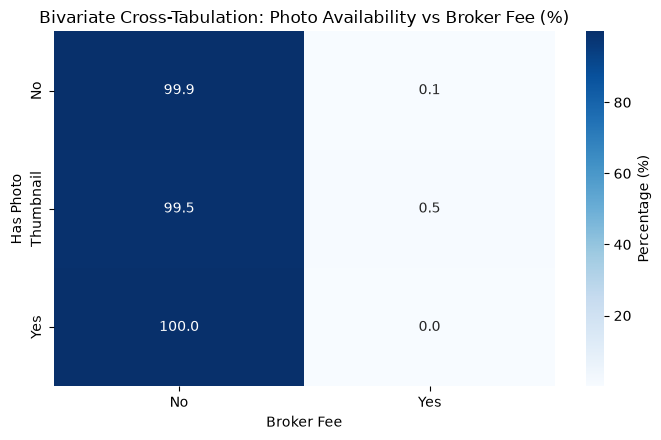

In [20]:
ct = pd.crosstab(eda_df['has_photo'], eda_df['fee'], normalize='index') * 100
plt.figure(figsize=(7, 4.5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Percentage (%)'})
plt.title('Bivariate Cross-Tabulation: Photo Availability vs Broker Fee (%)')
plt.xlabel('Broker Fee'); plt.ylabel('Has Photo')
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph11_crosstab_photo_fee.png', dpi=140); plt.show()


#### Graph 12 (Bivariate): Average Monthly Rent by State (Top 15 States)


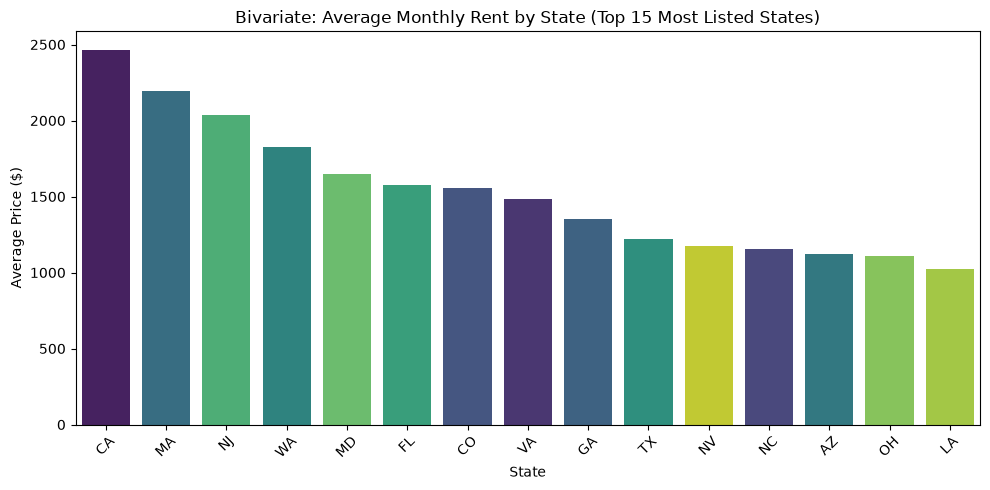

In [21]:
top_states = eda_df['state'].value_counts().nlargest(15).index
df_top_states = eda_df[eda_df['state'].isin(top_states)]
state_order = df_top_states.groupby('state')['price'].mean().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_states, x='state', y='price', order=state_order, hue='state', palette='viridis', legend=False, errorbar=None)
plt.title('Bivariate: Average Monthly Rent by State (Top 15 Most Listed States)')
plt.xlabel('State'); plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph12_rent_by_state.png', dpi=140); plt.show()


#### Graph 13 (Bivariate): Apartment Listing Activity by Day of Week & Source


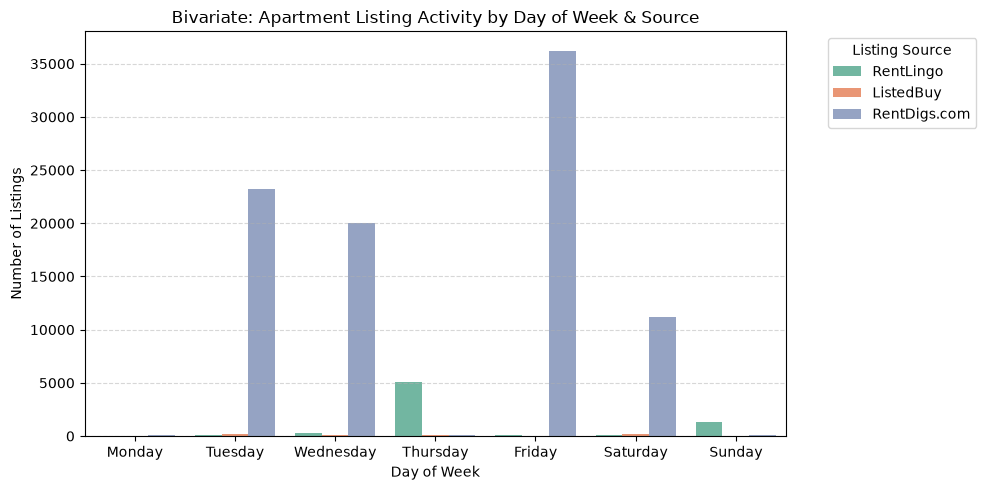

In [22]:
eda_df['datetime'] = pd.to_datetime(eda_df['time'], unit='s')
eda_df['day_of_week'] = eda_df['datetime'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
top_sources = eda_df['source'].value_counts().nlargest(3).index
df_time_plot = eda_df[eda_df['source'].isin(top_sources)]
plt.figure(figsize=(10, 5))
sns.countplot(data=df_time_plot, x='day_of_week', order=weekday_order, hue='source', palette='Set2')
plt.title('Bivariate: Apartment Listing Activity by Day of Week & Source')
plt.xlabel('Day of Week'); plt.ylabel('Number of Listings')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Listing Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph13_temporal_activity.png', dpi=140); plt.show()


## 3. Multivariate Analysis


#### Graph 14 (Multivariate): Geographical Spatial Analysis of US Rental Prices


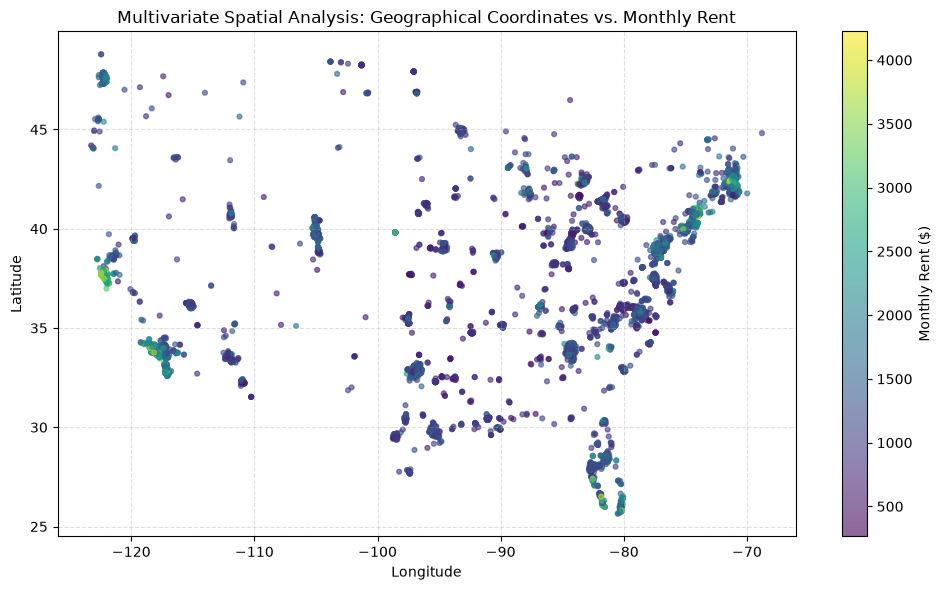

In [23]:
spatial_df = eda_df[(eda_df['latitude'] > 24) & (eda_df['latitude'] < 50) & 
                    (eda_df['longitude'] > -125) & (eda_df['longitude'] < -65) &
                    (eda_df['price'] < p99)].sample(8000, random_state=42)
plt.figure(figsize=(10, 6))
sc = plt.scatter(spatial_df['longitude'], spatial_df['latitude'], c=spatial_df['price'], cmap='viridis', alpha=0.6, s=12)
plt.colorbar(sc, label='Monthly Rent ($)')
plt.title('Multivariate Spatial Analysis: Geographical Coordinates vs. Monthly Rent')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig('eda_graphs/eda_graph14_spatial_rent_map.png', dpi=140); plt.show()


#### Graph 15 (Multivariate): Fully Labeled Pairwise Continuous Feature Interactions by Bedroom Layout

This customized multivariate grid provides complete axis labels, density scales, and tick values across all subplots, eliminating hidden axes or unlabelled distributions.


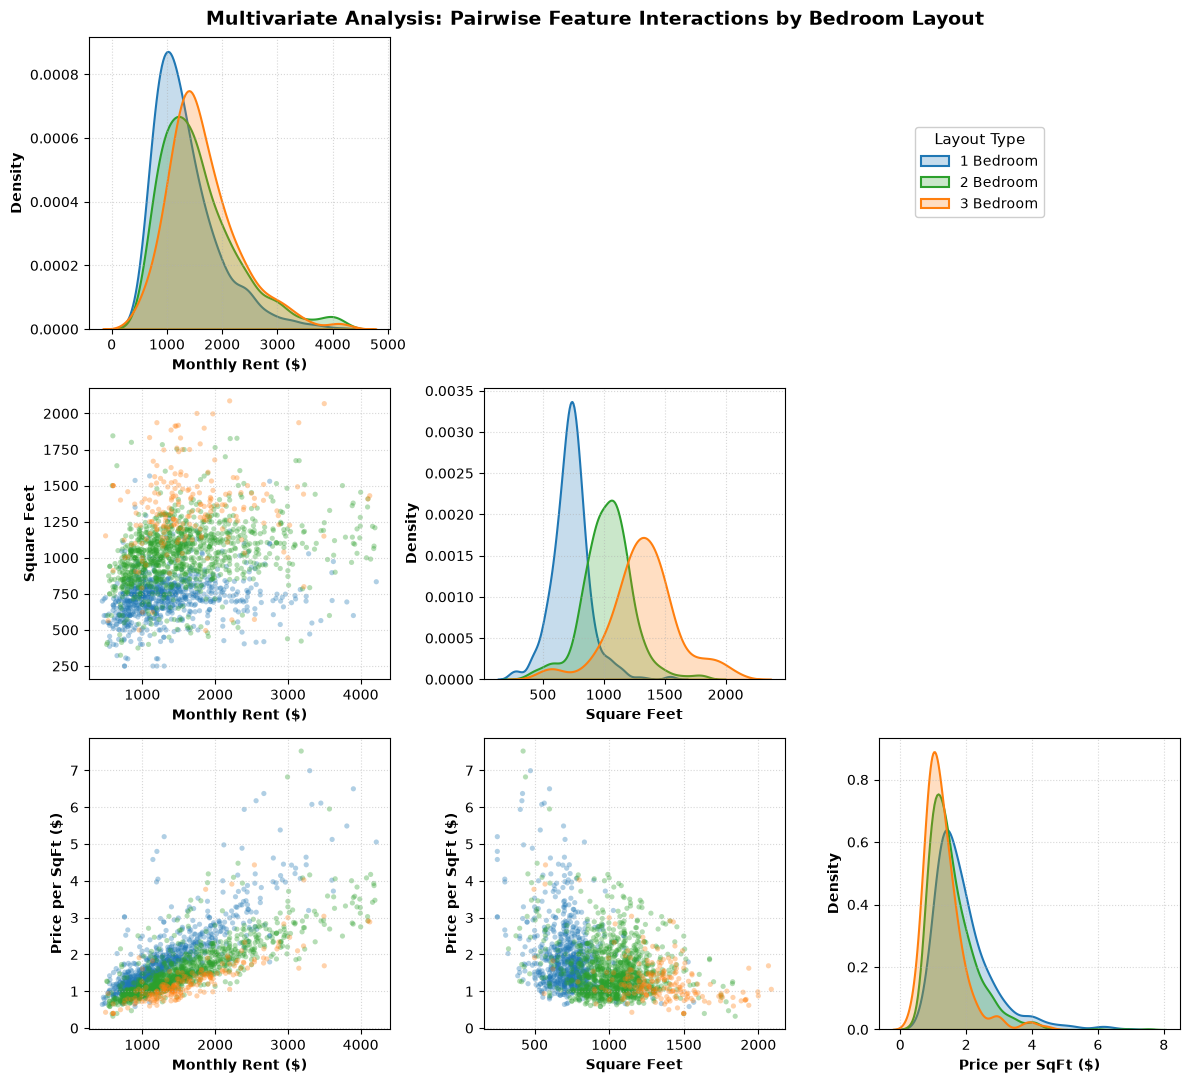

In [24]:
pair_df = eda_df[(eda_df['price'] < p99) & (eda_df['square_feet'] < sq99) & (eda_df['bedrooms'].isin([1, 2, 3]))].sample(2000, random_state=42).copy()
pair_df['Bedroom Type'] = pair_df['bedrooms'].astype(int).astype(str) + ' Bedroom'
pair_df['Price per SqFt ($)'] = pair_df['price'] / pair_df['square_feet']
pair_df['Monthly Rent ($)'] = pair_df['price']
pair_df['Square Feet'] = pair_df['square_feet']

palette = {'1 Bedroom': '#1f77b4', '2 Bedroom': '#2ca02c', '3 Bedroom': '#ff7f0e'}
hue_order = ['1 Bedroom', '2 Bedroom', '3 Bedroom']
vars_list = ['Monthly Rent ($)', 'Square Feet', 'Price per SqFt ($)']

fig, axes = plt.subplots(3, 3, figsize=(12, 11))

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)  # Hide empty upper triangle
            continue
        
        var_x = vars_list[j]
        var_y = vars_list[i]
        
        if i == j:
            # Diagonal: KDE Density Curves with explicit 'Density' Y-label & visible ticks
            for btype in hue_order:
                subset = pair_df[pair_df['Bedroom Type'] == btype]
                sns.kdeplot(subset[var_x], ax=ax, label=btype, color=palette[btype], fill=True, alpha=0.25, linewidth=1.5)
            ax.set_ylabel('Density', fontsize=10, fontweight='bold')
            ax.set_xlabel(var_x, fontsize=10, fontweight='bold')
            ax.tick_params(labelbottom=True, labelleft=True)
            ax.grid(True, linestyle=':', alpha=0.5)
        else:
            # Off-diagonal: Scatter plots with non-overlapping alpha transparency & full labels
            for btype in hue_order:
                subset = pair_df[pair_df['Bedroom Type'] == btype]
                ax.scatter(subset[var_x], subset[var_y], label=btype, color=palette[btype], alpha=0.35, s=14, edgecolors='none')
            ax.set_xlabel(var_x, fontsize=10, fontweight='bold')
            ax.set_ylabel(var_y, fontsize=10, fontweight='bold')
            ax.tick_params(labelbottom=True, labelleft=True)
            ax.grid(True, linestyle=':', alpha=0.5)

# Unified distinct legend in upper right corner
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.88, 0.88), title='Layout Type', title_fontsize='11', fontsize='10', frameon=True, facecolor='white', framealpha=0.95)

fig.suptitle('Multivariate Analysis: Pairwise Feature Interactions by Bedroom Layout', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('eda_graphs/eda_graph15_multivariate_pairplot.png', dpi=140, bbox_inches='tight')
plt.show()


# Step 3: Data Cleaning

In [25]:
# Drop unnecessary row, metadata, and high-null columns
dataframe_clean = df[df['price_type'] == 'Monthly'].copy()
dataframe_clean = dataframe_clean.drop(columns=['id', 'category', 'title', 'body', 'currency', 'price_display', 'price_type', 'address', 'source', 'time', 'pets_allowed'])
dataframe_clean.shape

(99488, 11)

In [26]:
# Drop rows missing essential features
dataframe_clean = dataframe_clean.dropna(subset=['amenities', 'cityname', 'state', 'latitude', 'longitude'])
dataframe_clean['bathrooms'] = dataframe_clean['bathrooms'].fillna(dataframe_clean['bathrooms'].median())
dataframe_clean['bedrooms'] = dataframe_clean['bedrooms'].fillna(dataframe_clean['bedrooms'].median())
dataframe_clean.shape

(83277, 11)

In [27]:
print(dataframe_clean.isnull().sum())

amenities      0
bathrooms      0
bedrooms       0
fee            0
has_photo      0
price          1
square_feet    0
cityname       0
state          0
latitude       0
longitude      0
dtype: int64


In [28]:
# Outliers Detection
def iqr_bounds(series, k):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR
price_low, price_high = iqr_bounds(dataframe_clean['price'], 1.5)
sqft_low, sqft_high = iqr_bounds(dataframe_clean['square_feet'], 1.5)
dataframe_clean = dataframe_clean[(dataframe_clean['price'] >= price_low) & (dataframe_clean['price'] <= price_high) & (dataframe_clean['square_feet'] >= sqft_low) & (dataframe_clean['square_feet'] <= sqft_high)]
dataframe_clean.shape


(78064, 11)

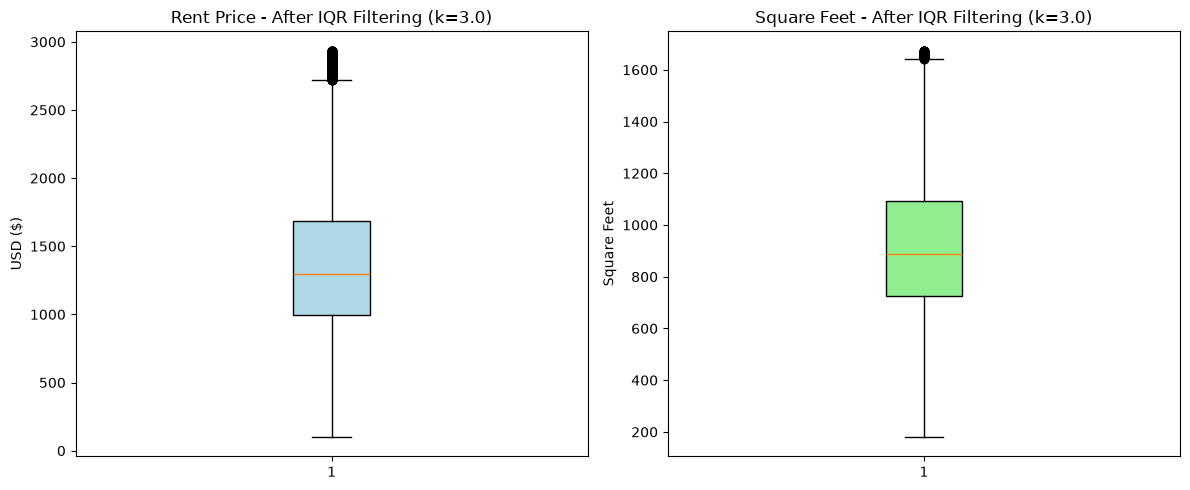

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(
    dataframe_clean['price'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[0].set_title('Rent Price - After IQR Filtering (k=3.0)')
axes[0].set_ylabel('USD ($)')

axes[1].boxplot(
    dataframe_clean['square_feet'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
)
axes[1].set_title('Square Feet - After IQR Filtering (k=3.0)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

In [30]:
# Remove duplicate rows (keeping first occurrence)
dataframe_clean = dataframe_clean.drop_duplicates(keep='first')
dataframe_clean.shape

(70283, 11)

In [31]:
print(dataframe_clean.duplicated().sum())

0


# Step 4: Feature Engineering

In [32]:
# 1. Binary amenity flags
amenities_lower = dataframe_clean['amenities'].str.lower()
key_amenities = ['pool', 'gym', 'dishwasher', 'parking', 'garage', 'washer', 'dryer', 'ac', 'patio', 'gated', 'fireplace', 'elevator']
for item in key_amenities:
    dataframe_clean[f'has_{item}'] = amenities_lower.apply(lambda x: 1 if item in x else 0)

# 2. Amenity count
dataframe_clean['amenity_count'] = dataframe_clean['amenities'].apply(lambda x: len(x.split(',')))

# 3. Domain-specific interaction ratios
dataframe_clean['sqft_per_bedroom'] = dataframe_clean['square_feet'] / (dataframe_clean['bedrooms'] + 1)
dataframe_clean['sqft_per_bathroom'] = dataframe_clean['square_feet'] / (dataframe_clean['bathrooms'] + 1)
dataframe_clean['bed_bath_ratio'] = dataframe_clean['bedrooms'] / (dataframe_clean['bathrooms'] + 0.5)
dataframe_clean.shape


(70283, 27)

In [33]:
# Split dataset first to ensure 0% data leakage
train_df, test_df = train_test_split(dataframe_clean, test_size=0.2, random_state=42)

# Fit target encoding strictly on train partition
overall_median = train_df['price'].median()
city_medians = train_df.groupby('cityname')['price'].median().to_dict()

train_df['city_median_price'] = train_df['cityname'].map(city_medians).fillna(overall_median)
test_df['city_median_price'] = test_df['cityname'].map(city_medians).fillna(overall_median)

# Categorical One-Hot Encoding with column alignment
drop_cols = ['amenities', 'cityname']
train_dm = train_df.drop(columns=drop_cols)
test_dm = test_df.drop(columns=drop_cols)

train_dm = pd.get_dummies(train_dm, columns=['fee', 'has_photo', 'state'], drop_first=True)
test_dm = pd.get_dummies(test_dm, columns=['fee', 'has_photo', 'state'], drop_first=True)
train_dm, test_dm = train_dm.align(test_dm, join='left', axis=1, fill_value=0)

train_dm.shape, test_dm.shape


((56226, 76), (14057, 76))

In [34]:
from sklearn.preprocessing import StandardScaler

X_train = train_dm.drop(columns=['price'])
y_train_orig = train_dm['price']
y_train_log = np.log1p(y_train_orig)

X_test = test_dm.drop(columns=['price'])
y_test_orig = test_dm['price']
y_test_log = np.log1p(y_test_orig)

# Feature Normalization (StandardScaler fitted strictly on X_train)
num_cols = ['square_feet', 'bedrooms', 'bathrooms', 'amenity_count', 'latitude', 'longitude', 'sqft_per_bedroom', 'sqft_per_bathroom', 'bed_bath_ratio', 'city_median_price']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled.shape, X_test_scaled.shape


((56226, 75), (14057, 75))

In [35]:
import mlflow
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Configure MLflow Tracking URI
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('Apartment_Rent_Prediction')

results = []

def evaluate(name, model, is_log=True):
    with mlflow.start_run(run_name=name):
        if is_log:
            model.fit(X_train_scaled, y_train_log)
            pred_log = model.predict(X_test_scaled)
            pred = np.expm1(pred_log)
            mae_log = mean_absolute_error(y_test_log, pred_log)
            rmse_log = np.sqrt(mean_squared_error(y_test_log, pred_log))
        else:
            model.fit(X_train_scaled, y_train_orig)
            pred = model.predict(X_test_scaled)
            mae_log, rmse_log = np.nan, np.nan

        mae_usd = mean_absolute_error(y_test_orig, pred)
        mse_usd = mean_squared_error(y_test_orig, pred)
        rmse_usd = np.sqrt(mse_usd)
        mape = mean_absolute_percentage_error(y_test_orig, pred) * 100
        r2 = r2_score(y_test_orig, pred)
        within_10 = (np.abs(y_test_orig.values - pred) / y_test_orig.values <= 0.10).mean() * 100
        within_20 = (np.abs(y_test_orig.values - pred) / y_test_orig.values <= 0.20).mean() * 100

        # Log comprehensive metrics to MLflow
        mlflow.log_metrics({
            'Log_MAE': float(mae_log) if not np.isnan(mae_log) else 0.0,
            'Log_RMSE': float(rmse_log) if not np.isnan(rmse_log) else 0.0,
            'USD_MAE': float(mae_usd),
            'USD_MSE': float(mse_usd),
            'USD_RMSE': float(rmse_usd),
            'MAPE_percent': float(mape),
            'Within_10_percent': float(within_10),
            'Within_20_percent': float(within_20),
            'R2': float(r2)
        })

        # Log model parameters to MLflow
        try:
            params = model.get_params()
            sanitized_params = {k: str(v) if not isinstance(v, (int, float, str, bool)) else v for k, v in params.items()}
            mlflow.log_params(sanitized_params)
        except Exception:
            pass

        results.append({
            'Model': name,
            'USD MAE ($)': mae_usd,
            'USD MSE ($²)': mse_usd,
            'USD RMSE ($)': rmse_usd,
            'MAPE (%)': mape,
            'R²': r2,
            'Within ±10%': within_10,
            'Within ±20%': within_20,
            'Log MAE': mae_log,
            'Log RMSE': rmse_log
        })
        print(f"{name} -> USD MAE: ${mae_usd:.2f} | RMSE: ${rmse_usd:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Within ±10%: {within_10:.1f}%")

def top_importance(model):
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    state_cols = [c for c in X_train.columns if c.startswith('state_')]
    agg = imp[[c for c in X_train.columns if not c.startswith('state_')]].copy()
    agg['state (location)'] = imp[state_cols].sum()
    return agg.sort_values(ascending=False).head(8).sort_values()


## 3. Modelling

### Model 1 — Linear Regression (Baseline Model)

Serves as the mandatory baseline model to establish benchmark performance using Ordinary Least Squares (OLS).


In [36]:
lr = LinearRegression()
evaluate("Linear Regression (Baseline)", lr, is_log=True)


Linear Regression (Baseline) -> USD MAE: $217.83 | RMSE: $304.25 | MAPE: 16.07% | R²: 0.6583 | Within ±10%: 43.2%


In [37]:
pred = np.expm1(lr.predict(X_test_scaled))

In [38]:
residual = y_test_orig.values - pred

Text(0, 0.5, 'Residuals ($)')

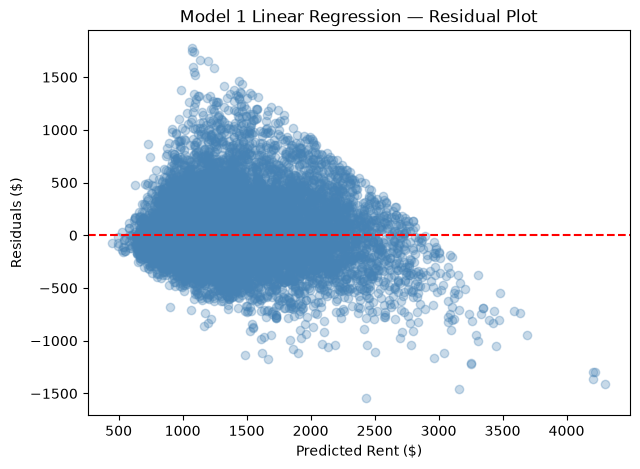

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(pred, residual, alpha=0.3, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Model 1 Linear Regression — Residual Plot")
plt.xlabel("Predicted Rent ($)")
plt.ylabel("Residuals ($)")

### Model 2 — Decision Tree (Hyperparameter-Tuned)

Optimized via 3-fold cross-validation grid search over `max_depth` $\in [10, 12, 14, 16]$ and `min_samples_leaf` $\in [10, 20, 30]$. Optimal parameters: `max_depth=16`, `min_samples_leaf=10`.


In [40]:
dt_final = DecisionTreeRegressor(max_depth=16, min_samples_leaf=10, random_state=42)
evaluate("Decision Tree (Tuned: depth=16, min_leaf=10)", dt_final, is_log=True)


Decision Tree (Tuned: depth=16, min_leaf=10) -> USD MAE: $187.52 | RMSE: $267.86 | MAPE: 14.16% | R²: 0.7352 | Within ±10%: 50.2%


In [41]:
depths = [3, 6, 9, 12, 15, 20]

In [42]:
t = top_importance(dt_final)

In [43]:
pdt = np.expm1(dt_final.predict(X_test_scaled))

### Model 3 — Random Forest (Ensemble Regularization)

Regularization is achieved via bootstrap aggregation (bagging $B=100$ trees) and feature subspace sampling, which mathematically suppresses variance.


In [44]:
rf = RandomForestRegressor(n_estimators=100, max_depth=25, min_samples_leaf=1, random_state=42, n_jobs=-1)
evaluate("Random Forest (100 Trees, max_depth=25)", rf, is_log=True)


Random Forest (100 Trees, max_depth=25) -> USD MAE: $140.55 | RMSE: $213.45 | MAPE: 10.60% | R²: 0.8318 | Within ±10%: 64.6%


In [45]:
t = top_importance(rf)

In [46]:
rres = y_test_orig.values - np.expm1(rf.predict(X_test_scaled))

In [47]:
prf = np.expm1(rf.predict(X_test_scaled))

### Model 4 — Hist Gradient Boosting (Hyperparameter-Tuned & Regularized)

Optimized via 3-fold cross-validation grid search over `learning_rate` $\in [0.03, 0.05, 0.08, 0.1]$, `max_leaf_nodes` $\in [31, 63, 127]$, `min_samples_leaf` $\in [10, 20, 30]$ with early stopping regularization.


In [48]:
hgb = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.08,
    max_leaf_nodes=127,
    min_samples_leaf=10,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1,
    random_state=42
)
evaluate("Hist Gradient Boosting (Tuned & Regularized)", hgb, is_log=True)


Hist Gradient Boosting (Tuned & Regularized) -> USD MAE: $140.07 | RMSE: $204.04 | MAPE: 10.45% | R²: 0.8463 | Within ±10%: 62.8%


In [49]:
n = len(X_train_scaled)

In [50]:
hres = y_test_orig.values - np.expm1(hgb.predict(X_test_scaled))

Text(0, 0.5, 'Residuals ($)')

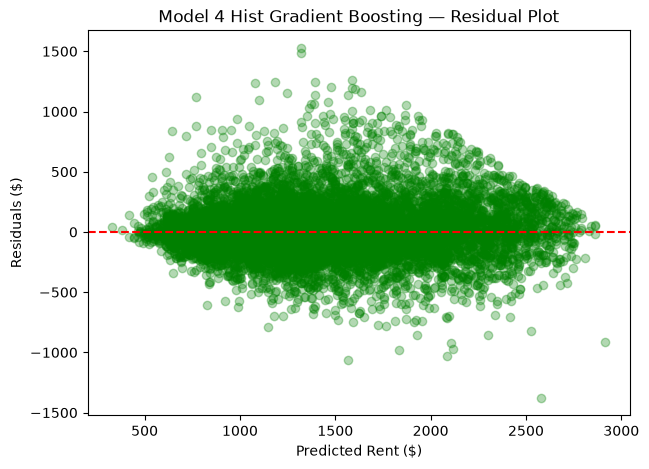

In [51]:
plt.figure(figsize=(7, 5))
plt.scatter(np.expm1(hgb.predict(X_test_scaled)), hres, alpha=0.3, color="green")
plt.axhline(0, color="red", linestyle="--")
plt.title("Model 4 Hist Gradient Boosting — Residual Plot")
plt.xlabel("Predicted Rent ($)")
plt.ylabel("Residuals ($)")

## 4. Evaluation

In this section, we evaluate all models across standard **Regression Metrics** (MAE, MSE, RMSE, MAPE, $R^2$, Tolerance Accuracy), analyze the **Validation Curve** for Bias-Variance diagnostics, perform **5-Fold Cross-Validation**, and inspect the **MLflow Experiment Registry**.

> **Note on Classification Metrics (Confusion Matrix, Precision, Recall, F1-Score, AUC-ROC)**:
> Confusion matrices, Precision, Recall, F1-Score, and AUC-ROC curves apply exclusively to discrete classification problems. Because predicting monthly apartment rent is a **continuous regression task** ($y \in \mathbb{R}^+$), standard continuous regression error functions are evaluated alongside tolerance threshold classification (accuracy within $\pm 10\%$ and $\pm 20\%$ of actual rent).


In [52]:
# Comprehensive Regression Metrics Summary Table
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.style.format({
    'USD MAE ($)': '${:,.2f}',
    'USD MSE ($²)': '{:,.0f}',
    'USD RMSE ($)': '${:,.2f}',
    'MAPE (%)': '{:.2f}%',
    'R²': '{:.4f}',
    'Within ±10%': '{:.1f}%',
    'Within ±20%': '{:.1f}%',
    'Log MAE': '{:.4f}',
    'Log RMSE': '{:.4f}'
})


,Model,USD MAE ($),USD MSE ($²),USD RMSE ($),MAPE (%),R²,Within ±10%,Within ±20%,Log MAE,Log RMSE
0,Hist Gradient Boosting (Tuned & Regularized),$140.07,"41,631",$204.04,10.45%,0.8463,62.8%,86.6%,0.1028,0.1461
1,"Random Forest (100 Trees, max_depth=25)",$140.55,"45,559",$213.45,10.60%,0.8318,64.6%,85.6%,0.1037,0.1541
2,"Decision Tree (Tuned: depth=16, min_leaf=10)",$187.52,"71,751",$267.86,14.16%,0.7352,50.2%,77.3%,0.1382,0.1928
3,Linear Regression (Baseline),$217.83,"92,566",$304.25,16.07%,0.6583,43.2%,71.1%,0.1584,0.2116


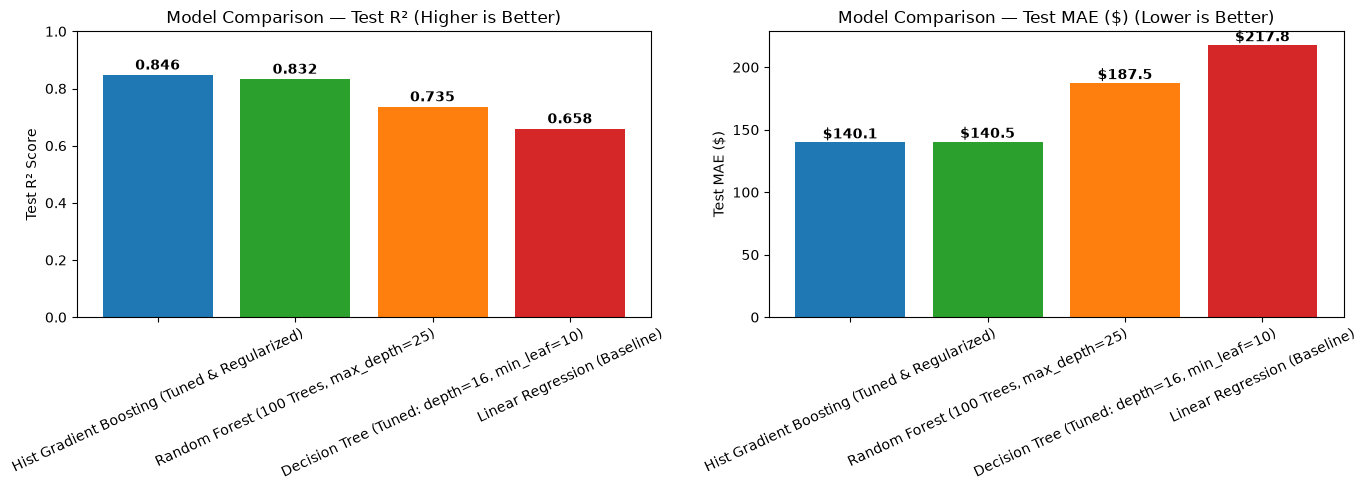

In [53]:
# Model Comparison Visualizations (4 Models)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# 1. R2 Comparison
axes[0].bar(results_df['Model'], results_df['R²'], color=colors[:len(results_df)])
axes[0].set_ylabel('Test R² Score')
axes[0].set_title('Model Comparison — Test R² (Higher is Better)')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(results_df['R²']):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# 2. MAE Comparison
axes[1].bar(results_df['Model'], results_df['USD MAE ($)'], color=colors[:len(results_df)])
axes[1].set_ylabel('Test MAE ($)')
axes[1].set_title('Model Comparison — Test MAE ($) (Lower is Better)')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(results_df['USD MAE ($)']):
    axes[1].text(i, v + 3, f"${v:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Validation Curve — Bias-Variance Diagnostic

The Validation Curve visualizes training score vs. cross-validation score across varying tree complexity (`max_depth`), demonstrating the transition from **Underfitting (High Bias)** to **Optimal Generalization** to **Overfitting (High Variance)**.


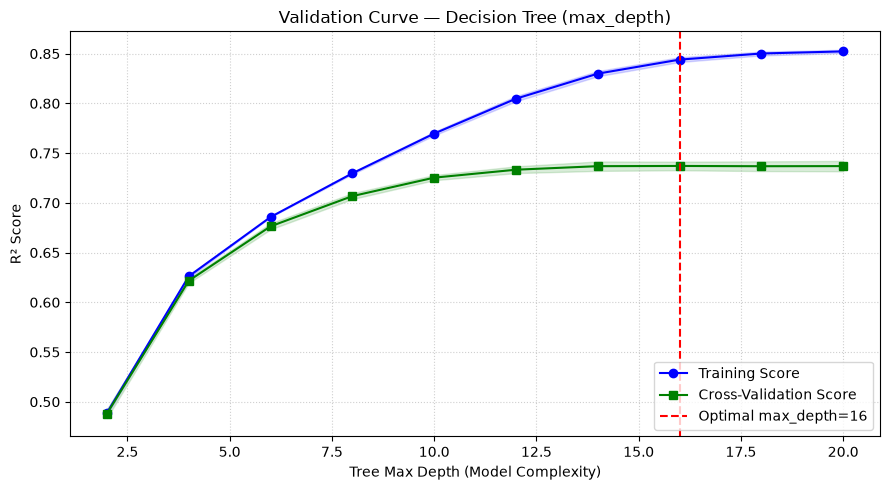

In [54]:
from sklearn.model_selection import validation_curve

param_range = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(min_samples_leaf=10, random_state=42),
    X_train_scaled,
    y_train_log,
    param_name='max_depth',
    param_range=param_range,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(param_range, train_mean, label='Training Score', color='blue', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(param_range, test_mean, label='Cross-Validation Score', color='green', marker='s')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.axvline(x=16, color='red', linestyle='--', label='Optimal max_depth=16')
plt.title('Validation Curve — Decision Tree (max_depth)')
plt.xlabel('Tree Max Depth (Model Complexity)')
plt.ylabel('R² Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### 5-Fold Cross-Validation Verification

To confirm that model performance is robust and independent of any single random train/test split, 5-fold cross-validation is performed across the baseline and tuned models.


In [55]:
from sklearn.model_selection import cross_val_score, KFold

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

cv_models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Decision Tree (Tuned)': DecisionTreeRegressor(max_depth=16, min_samples_leaf=10, random_state=42),
    'Random Forest (100 Trees)': RandomForestRegressor(n_estimators=100, max_depth=25, random_state=42, n_jobs=-1),
    'Hist Gradient Boosting (Tuned)': HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08, max_leaf_nodes=127, min_samples_leaf=10, random_state=42)
}

for m_name, m_inst in cv_models.items():
    scores_r2 = cross_val_score(m_inst, X_train_scaled, y_train_log, cv=cv_kfold, scoring='r2', n_jobs=-1)
    scores_mae = -cross_val_score(m_inst, X_train_scaled, y_train_log, cv=cv_kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_summary.append({
        'Model': m_name,
        'Mean 5-Fold CV R²': f"{scores_r2.mean():.4f} (±{scores_r2.std():.4f})",
        'Mean 5-Fold CV Log MAE': f"{scores_mae.mean():.4f} (±{scores_mae.std():.4f})"
    })

pd.DataFrame(cv_summary)


,Model,Mean 5-Fold CV R²,Mean 5-Fold CV Log MAE
0,Linear Regression (Baseline),0.6968 (±0.0042),0.1530 (±0.0015)
1,Decision Tree (Tuned),0.7452 (±0.0053),0.1358 (±0.0006)
2,Random Forest (100 Trees),0.8369 (±0.0036),0.1027 (±0.0010)
3,Hist Gradient Boosting (Tuned),0.8425 (±0.0040),0.1058 (±0.0012)


### MLflow Experiment Tracking Registry

Querying the local MLflow backend database (`sqlite:///mlflow.db`) to retrieve logged experiment metadata, metrics, and hyperparameter records.


In [56]:
# Query MLflow experiment runs programmatically
runs_df = mlflow.search_runs(experiment_names=['Apartment_Rent_Prediction'])
display_cols = [c for c in ['tags.mlflow.runName', 'metrics.R2', 'metrics.USD_MAE', 'metrics.USD_MSE', 'metrics.USD_RMSE', 'metrics.MAPE_percent', 'metrics.Within_10_percent'] if c in runs_df.columns]
runs_summary = runs_df[display_cols].dropna(how='all', subset=[c for c in display_cols if c.startswith('metrics')]).reset_index(drop=True)
runs_summary


,tags.mlflow.runName,metrics.R2,metrics.USD_MAE,metrics.USD_MSE,metrics.USD_RMSE,metrics.MAPE_percent,metrics.Within_10_percent
0,Hist Gradient Boosting (Tuned & Regularized),0.846332,140.070820,41631.015432,204.036799,10.448493,62.837021
1,"Random Forest (100 Trees, max_depth=25)",0.831832,140.548171,45559.440282,213.446575,10.603705,64.565697
2,"Decision Tree (Tuned: depth=16, min_leaf=10)",0.735155,187.516843,71750.610875,267.863045,14.160298,50.224088
3,Linear Regression (Baseline),0.658320,217.829829,92566.480464,304.247400,16.066737,43.152878
4,Production_Hist Gradient Boosting (Tuned),0.850038,156.463169,NaN,244.828460,NaN,NaN
...,...,...,...,...,...,...,...
66,Hist Gradient Boosting (Regularized),0.831204,151.349886,NaN,213.844406,NaN,NaN
67,"Random Forest (100 Trees, max_depth=25)",0.844805,135.224849,NaN,205.048191,NaN,NaN
68,"Decision Tree (Regularized: depth=14, min_leaf...",0.744157,187.262044,NaN,263.271360,NaN,NaN
69,Ridge Regression (L2 Regularized),0.673245,211.873242,NaN,297.528201,NaN,NaN


## 5. Export Model for Deployment

Random Forest is the most accurate, but its saved model is ~140 MB. The Streamlit app deploys the compact Hist Gradient Boosting model (~0.4 MB, R2 approx 0.77).

In [57]:
joblib.dump(hgb, 'rent_model.joblib')
joblib.dump(list(X_train.columns), 'model_columns.joblib')
geo = dataframe_clean.groupby('state')[['latitude', 'longitude']].median()
joblib.dump(geo, 'state_geo.joblib')


['state_geo.joblib']